# ALMA Archive Tool Usage Guide

This notebook demonstrates how to call the two scripts in this workspace to query the ALMA archive and convert the results to a DS9 region file:

1. `search_alma.py`: Queries the ALMA archive using RA, Dec, and Radius.
2. `csv_to_ds9.py`: Converts the query results into a format readable by the SAOImage DS9 tool (`.reg` files).

## 1. Setup and Import Modules

We first ensure that our local workspace path is in `sys.path` so we can import our scripts as Python modules.

In [2]:
import sys
import os
import pandas as pd

# Add the current directory to sys.path so we can import local scripts
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)

import search_alma
import csv_to_ds9

/Users/mingyu/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Querying the ALMA Archive

We will define our target coordinates directly. By calling `search_alma.query_alma_archive`, the ALMA database is queried and the result is saved automatically to `alma_query_results.csv`.

In [3]:
# Set target coordinates and search radius
target_ra = 53.0829375
target_dec = -27.8556305
search_radius = 0.0001 # degrees

print("Starting ALMA database query...")
print(f"Target HA: {target_ra}, Dec: {target_dec}, Radius: {search_radius} degrees\n")

# Execute query (this generates 'alma_query_results.csv' in the working directory)
search_alma.query_alma_archive(ra=target_ra, dec=target_dec, radius_deg=search_radius)

Starting ALMA database query...
Target HA: 53.0829375, Dec: -27.8556305, Radius: 0.0001 degrees

Searching ALMA archive around RA=53.0829375, Dec=-27.8556305 with radius=0.0001 deg...

Successfully saved all 102 raw results to alma_query_results.csv

Found 102 observations. Extracting core info...

Project Code    | Source Name          | Band  | Footprint (s_region)
----------------------------------------------------------------------------------------------------
2021.1.00024.S  | cdfs31               | 3     | Circle ICRS 53.077375 -27.859611 0.007830
2021.1.00024.S  | cdfs31               | 3     | Circle ICRS 53.077375 -27.859611 0.007830
2021.1.00024.S  | cdfs31               | 3     | Circle ICRS 53.077375 -27.859611 0.007830
2021.1.00024.S  | cdfs31               | 3     | Circle ICRS 53.077375 -27.859611 0.007830
2021.1.00547.S  | CANDELS_-_GOODS_South | 3     | Union ICRS ( Polygon 53.104372 -27.858393 53.10...
2021.1.00547.S  | CANDELS_-_GOODS_South | 3     | Union ICRS ( P

## 3. Convert CSV to DS9 Regions

Now that we have the CSV created locally with FOV (Field of View) limits or polygons from ALMA, we will parse it and generate an `.reg` file layout, preserving useful information to overlay on FITS maps.

In [4]:
# Assign the expected files
input_csv_file = "alma_query_results.csv"
output_reg_file = "alma_regions.reg"

print(f"Converting '{input_csv_file}' to DS9 region format -> '{output_reg_file}'...")

# Pass to our converter 
csv_to_ds9.convert_csv_to_ds9(input_csv=input_csv_file, output_reg=output_reg_file)

print("Conversion complete!")

Converting 'alma_query_results.csv' to DS9 region format -> 'alma_regions.reg'...
Successfully converted 126 regions into alma_regions.reg
Conversion complete!


## 4. Output Summary and Verification

We can inspect the output variables to confirm it matches expectations. Run this cell to peek at the first 3 results inside the Pandas dataframe and the first 5 lines of the generated region file respectively.

In [5]:
# 4.1 Show CSV snapshot
if os.path.exists(input_csv_file):
    df_results = pd.read_csv(input_csv_file)
    print(f"=== ALMA CSV Summary ===")
    print(f"Total Rows: {len(df_results)}")
    print(f"Total Columns: {len(df_results.columns)}")
    display(df_results.head(3))
else:
    print(f"Error: {input_csv_file} was not found.")

print("\n" + "="*50 + "\n")

# 4.2 Show DS9 output snapshot
if os.path.exists(output_reg_file):
    print(f"=== Output '{output_reg_file}' (First 5 lines) ===")
    with open(output_reg_file, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i < 5:
                print(line.strip())
            else:
                break
else:
    print(f"Error: {output_reg_file} was not found.")

=== ALMA CSV Summary ===
Total Rows: 102
Total Columns: 73


,obs_publisher_did,obs_collection,facility_name,instrument_name,obs_id,dataproduct_type,calib_level,collections,target_name,s_ra,...,science_observation,spatial_scale_max,qa2_passed,bib_reference,science_keyword,scientific_category,pi_userid,pi_name,spectral_resolution,lastModified
0,ADS/JAO.ALMA#2021.1.00024.S,ALMA,JAO,ALMA,uid://A001/X1590/X35b7.source.cdfs31.spw.25,cube,2,NaN,cdfs31,53.077375,...,T,12.121831,T,2023ApJ...951...48M 2023ApJ...952...28C 2025A&...,Sub-mm Galaxies (SMG);null,Galaxy evolution,franzbauer,"Bauer, Franz",3904.296875,2026-03-16T19:30:42.003
1,ADS/JAO.ALMA#2021.1.00024.S,ALMA,JAO,ALMA,uid://A001/X1590/X35b7.source.cdfs31.spw.27,cube,2,NaN,cdfs31,53.077375,...,T,12.121831,T,2023ApJ...951...48M 2023ApJ...952...28C 2025A&...,Sub-mm Galaxies (SMG);null,Galaxy evolution,franzbauer,"Bauer, Franz",3904.296875,2026-03-16T19:30:42.003
2,ADS/JAO.ALMA#2021.1.00024.S,ALMA,JAO,ALMA,uid://A001/X1590/X35b7.source.cdfs31.spw.29,cube,2,NaN,cdfs31,53.077375,...,T,12.121831,T,2023ApJ...951...48M 2023ApJ...952...28C 2025A&...,Sub-mm Galaxies (SMG);null,Galaxy evolution,franzbauer,"Bauer, Franz",3904.296875,2026-03-16T19:30:42.003




=== Output 'alma_regions.reg' (First 5 lines) ===
# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
fk5
circle(53.077375,-27.859611,0.007830) # color=red text={cdfs31}
circle(53.077375,-27.859611,0.007830) # color=red text={cdfs31}


## 5. Visualizing the Query Region and ALMA Footprint

We can extract the `s_region` or `footprint` information directly from the pandas DataFrame and use `matplotlib` to plot the target search region along with the overlapping ALMA observation footprints.

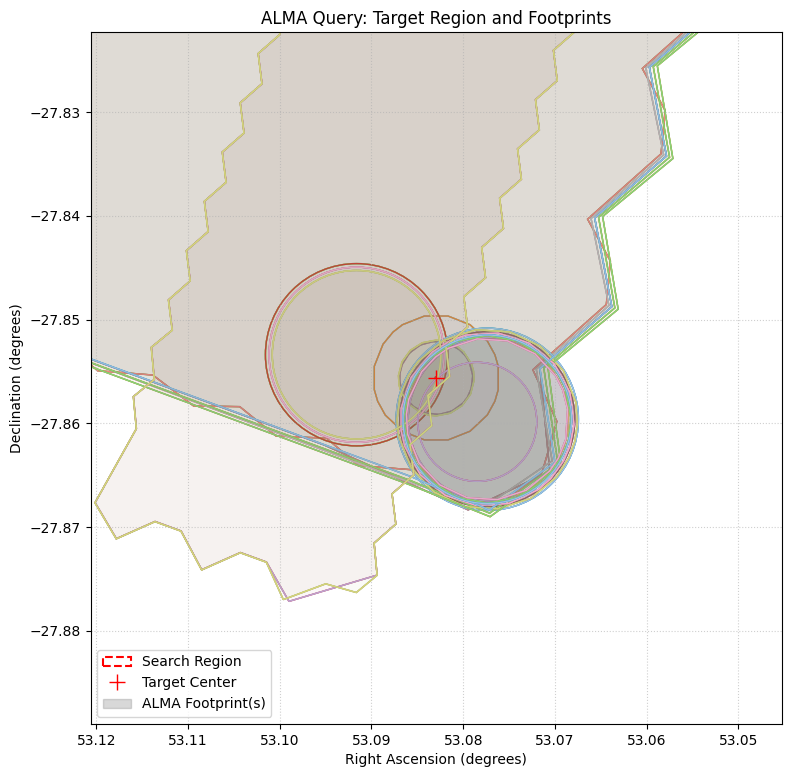

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon, Ellipse as MplEllipse, Patch
import numpy as np
import re

fig, ax = plt.subplots(figsize=(8, 8))

# Correct aspect ratio considering the declination
cos_dec = np.cos(np.radians(target_dec))
ax.set_aspect(1.0 / cos_dec)

# 1. Plot the target query region (as a circle on the sky, which is an ellipse in RA/Dec space)
target_coords = (target_ra, target_dec)
search_circle = MplEllipse(
    target_coords, width=2 * search_radius / cos_dec, height=2 * search_radius, 
    color='red', fill=False, linestyle='--', 
    linewidth=1.5, label='Search Region'
)
ax.add_patch(search_circle)
ax.plot(target_ra, target_dec, 'r+', markersize=12, label='Target Center')

# 2. Add ALMA footprints from our queried CSV
colors = plt.cm.tab20.colors
count = 0

s_region_col = 's_region' if 's_region' in df_results.columns else ('footprint' if 'footprint' in df_results.columns else None)

if s_region_col:
    for idx, row in df_results.iterrows():
        s_reg = str(row[s_region_col])
        if s_reg.lower() in ('nan', 'none', ''):
            continue
            
        color = colors[count % len(colors)]
        count += 1
        
        # Parse Polygons and Circles geometry strings
        tokens = re.split(r'(?i)\b(polygon|circle)\b', s_reg)
        current_geom = None
        
        for token in tokens:
            token_lower = token.strip().lower()
            if token_lower in ('polygon', 'circle'):
                current_geom = token_lower
            elif current_geom:
                # Extract coordinates as floats
                numbers = [float(n) for n in re.findall(r'[-+]?\d*\.\d+|\d+', token)]
                
                if current_geom == 'polygon' and len(numbers) >= 6:
                    # Create coordinate pairs (RA, Dec)
                    pts = np.array(numbers).reshape(-1, 2)
                    poly = MplPolygon(pts, closed=True, fill=True, alpha=0.01, 
                                      edgecolor=color, facecolor=color)
                    ax.add_patch(poly)
                    poly = MplPolygon(pts, closed=True, fill=False, alpha=0.8, 
                                      edgecolor=color, facecolor=color)
                    ax.add_patch(poly)
                elif current_geom == 'circle' and len(numbers) >= 3:
                    ra, dec, r = numbers[0], numbers[1], numbers[2]
                    # To remain circular on screen, represent as Ellipse with adjusted RA-width
                    circ = MplEllipse((ra, dec), width=2 * r / cos_dec, height=2 * r, 
                                      fill=True, alpha=0.01, 
                                      edgecolor=color, facecolor=color)
                    ax.add_patch(circ)
                    circ = MplEllipse((ra, dec), width=2 * r / cos_dec, height=2 * r, 
                                      fill=False, alpha=0.9, 
                                      edgecolor=color, facecolor=color)
                    ax.add_patch(circ)
                    
                current_geom = None

# Force layout autoscale
ax.autoscale_view()

# In Astronomy, RA typically decreases towards the right
ax.invert_xaxis()

# Decorate and label the plot axes
plt.xlabel('Right Ascension (degrees)')
plt.ylabel('Declination (degrees)')
plt.title('ALMA Query: Target Region and Footprints')

# Legend items
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='grey', alpha=0.3, edgecolor='grey'))
labels.append('ALMA Footprint(s)')
ax.legend(handles, labels)

# X Y limit to 2 arcmin
ra_lim = 2 / 60 / cos_dec
dec_lim = 2 / 60
ax.set_xlim(target_ra + ra_lim, target_ra - ra_lim)
ax.set_ylim(target_dec - dec_lim, target_dec + dec_lim)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('alma_footprints.png', dpi=100)
plt.show()